#### Prepared for Gabor's Data Analysis

### Data Analysis for Business, Economics, and Policy
by Gabor Bekes and  Gabor Kezdi
 
Cambridge University Press 2021

**[gabors-data-analysis.com ](https://gabors-data-analysis.com/)**

 License: Free to share, modify and use for educational purposes. 
 Not to be used for commercial purposes.

### Chapter 19
**CH19A Food and health**

using the food-health dataset

version 1.0 2021-05-05

In [15]:
import os
import sys
import warnings

import pandas as pd
import statsmodels.formula.api as smf
from IPython.core.display import HTML
from plotnine import *
from stargazer.stargazer import Stargazer

import numpy as np
from sklearn.linear_model import LinearRegression

import matplotlib.pyplot as plt

warnings.filterwarnings('ignore')


___

In [2]:
# !!! make sure you have run ch19-food-health.ipynb before
data = pd.read_csv("/workspaces/codespaces-jupyter/data/food-health.csv")

In [3]:
data

,Unnamed: 0,seqn,food_code,days,grams,vitaminc,alcohol,caffeine,cholesterol,year,...,bp_diastolic,total_cholesterol,hdl,weight,height,ldl,bmi,normal_weight,blood_pressure,heart_risk
0,0,51624.0,13110100.0,1.0,268.25,1.6,0.0,0.0,118.0,2009.0,...,88.0,50.0,135.0,87.4,164.7,85.0,32.219903,0,202.0,287.0
1,1,51628.0,92410310.0,1.0,491.20,0.0,0.0,39.0,0.0,2009.0,...,70.0,45.0,202.0,116.8,166.0,157.0,42.386413,0,224.0,381.0
2,2,51629.0,53106050.0,2.0,122.86,0.0,0.0,3.5,46.5,2009.0,...,50.0,45.0,160.0,97.6,173.0,115.0,32.610512,0,152.0,267.0
3,3,51630.0,63101000.0,1.0,223.00,10.3,0.0,0.0,0.0,2009.0,...,82.0,45.0,259.0,86.7,168.4,214.0,30.572779,0,200.0,414.0
4,4,51633.0,51300150.0,1.0,32.25,0.0,0.0,0.0,0.0,2009.0,...,62.0,75.0,182.0,79.1,174.3,107.0,26.036446,0,204.0,311.0
...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...
16479,16479,83721.0,93401020.0,1.0,150.00,0.0,15.5,0.0,0.0,2013.0,...,70.0,55.0,138.0,79.5,176.2,83.0,25.606801,0,178.0,261.0
16480,16480,83723.0,58100125.0,1.0,278.00,3.6,0.0,0.0,33.0,2013.0,...,NaN,49.0,186.0,99.5,173.5,137.0,33.054008,0,NaN,NaN
16481,16481,83724.0,24201120.0,1.0,51.00,0.0,0.0,0.0,39.0,2013.0,...,70.0,51.0,157.0,77.1,176.0,106.0,24.890238,1,234.0,340.0
16482,16482,83727.0,54403020.0,1.0,88.00,0.0,0.0,0.0,0.0,2013.0,...,68.0,55.0,190.0,71.8,171.3,135.0,24.468634,1,178.0,313.0


In [4]:
workfile = data.query("age>=30&age<60")

In [5]:
# new variables: 
  ## Fruit and vegetables per day (grams)
  ## Blood pressure (systolic+diastolic)

In [6]:
workfile = workfile.rename(columns={"veggies_n_fruits_gr":"fv","blood_pressure":"bp"})

In [7]:
workfile["fv"].describe()

count    7930.000000
mean      261.058836
std       285.358857
min         0.000000
25%        52.081874
50%       186.840000
75%       378.932500
max      5047.000000
Name: fv, dtype: float64

In [8]:
workfile["bp"].describe()

count    7360.000000
mean      193.708288
std        23.736936
min       129.000000
25%       178.000000
50%       192.000000
75%       208.000000
max       300.000000
Name: bp, dtype: float64

In [9]:
workfile = (
    workfile.loc[workfile["fv"] < 3200].dropna(subset=["bp"]).reset_index(drop=True)
)

In [10]:
# Days per week exercising
workfile["exerc"] = None
workfile.loc[workfile["paq655"] <= 7, "exerc"] = workfile["paq655"]
workfile.loc[workfile["paq650"] == 2, "exerc"] = 0
workfile["exerc"] = pd.to_numeric(workfile["exerc"])

In [11]:
# Potato chips per day, grams
workfile = workfile.rename(columns={"gr_potato_chips": "pchips"})

In [12]:
workfile = workfile.rename(columns={"gr_potato_chips": "pchips"})

### Descriptive table

In [13]:
(
    workfile[["bp", "fv"]]
    .describe()
    .rename(
        columns={
            "bp": "Blood pressure (systolic+diastolic)",
            "fv": "Fruit and vegetables per day (grams)",
        }
    )
    .T.rename(
        columns={
            "50%": "Median",
            "mean": "Mean",
            "count": "Observations",
            "max": "Maximum",
            "min": "Minimum",
            "std": "Std.Dev.",
        }
    )
    .round()
    .astype(int)
    .filter(["Mean", "Median", "Std.Dev.", "Minimum", "Maximum", "Observations"])
)

,Mean,Median,Std.Dev.,Minimum,Maximum,Observations
Blood pressure (systolic+diastolic),194,192,24,129,300,7358
Fruit and vegetables per day (grams),260,188,274,0,2740,7358


### SCATTERPLOT AND REGRESSION LINE 

In [14]:
# Blood pressure vs amount of fruit and vegetables
reg = smf.ols("bp ~ fv", data=workfile).fit()
print(reg.summary())

                            OLS Regression Results                            
Dep. Variable:                     bp   R-squared:                       0.002
Model:                            OLS   Adj. R-squared:                  0.002
Method:                 Least Squares   F-statistic:                     15.47
Date:                Tue, 26 Aug 2025   Prob (F-statistic):           8.44e-05
Time:                        20:30:53   Log-Likelihood:                -33736.
No. Observations:                7358   AIC:                         6.748e+04
Df Residuals:                    7356   BIC:                         6.749e+04
Df Model:                           1                                         
Covariance Type:            nonrobust                                         
                 coef    std err          t      P>|t|      [0.025      0.975]
------------------------------------------------------------------------------
Intercept    194.7421      0.381    510.939      0.0

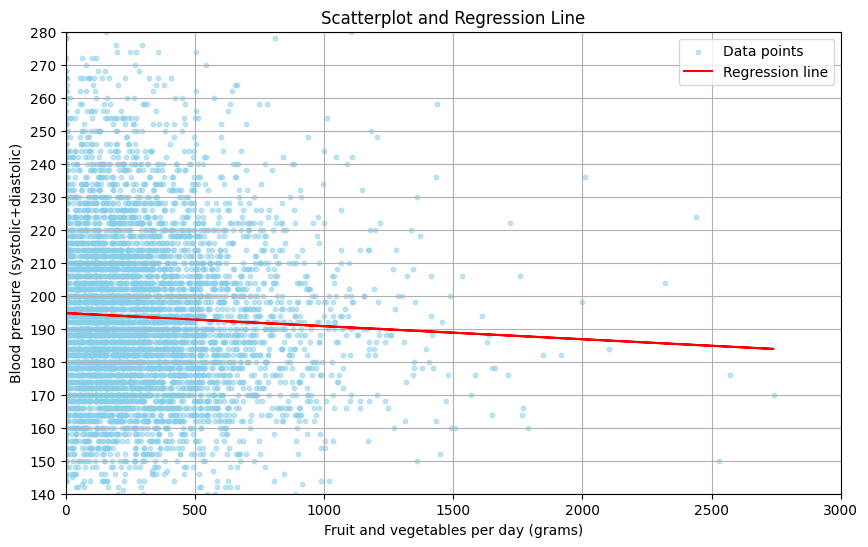

In [ ]:
# Extract data
x = workfile["fv"]
y = workfile["bp"]

# Fit a linear regression model
model = LinearRegression()
x_reshaped = x.values.reshape(-1, 1)
model.fit(x_reshaped, y)
y_pred = model.predict(x_reshaped)

# Create the plot
plt.figure(figsize=(10, 6))
plt.scatter(x, y, s=10, alpha=0.5, color="skyblue", label="Data points")
plt.plot(x, y_pred, color="red", label="Regression line")
plt.xlim(0, 3000)x
plt.ylim(140, 280)
plt.xticks(np.arange(0, 3001, 500))
plt.yticks(np.arange(140, 281, 10))
plt.xlabel("Fruit and vegetables per day (grams)")
plt.ylabel("Blood pressure (systolic+diastolic)")
plt.title("Scatterplot and Regression Line")
plt.legend()
plt.grid(True)
plt.show()

In [18]:
# regression line only

x = workfile["fv"]
y = workfile["bp"]

# Fit a linear regression model
model = LinearRegression()
x_reshaped = x.values.reshape(-1, 1)
model.fit(x_reshaped, y)
y_pred = model.predict(x_reshaped)

# Create the plot
plt.figure(figsize=(10, 6))
#plt.scatter(x, y, s=10, alpha=0.5, color="skyblue", label="Data points")
plt.plot(x, y_pred, color="red", label="Regression line")
plt.xlim(0, 3000)x
plt.ylim(140, 280)
plt.xticks(np.arange(0, 3001, 500))
plt.yticks(np.arange(140, 281, 10))
plt.xlabel("Fruit and vegetables per day (grams)")
plt.ylabel("Blood pressure (systolic+diastolic)")
plt.title("Scatterplot and Regression Line")
plt.legend()
plt.grid(True)
plt.show()

SyntaxError: invalid syntax (810569448.py, line 16)

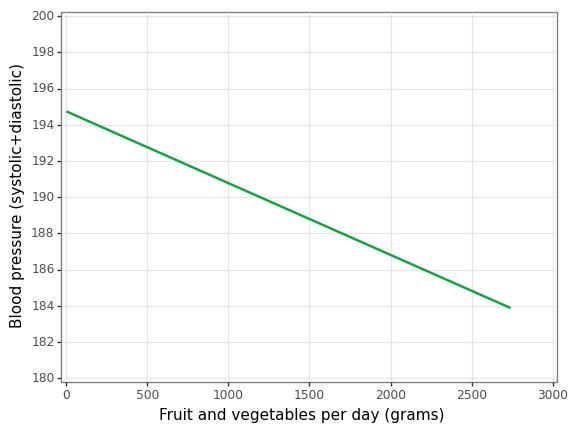

<ggplot: (377914106)>

In [18]:
# regression line only

(
    ggplot(workfile, aes(x="fv", y="bp"))
    + geom_smooth(method="lm", se=False, color=color[1])
    + theme_bw()
    + labs(
        x="Fruit and vegetables per day (grams)",
        y="Blood pressure (systolic+diastolic)",
    )
    + scale_y_continuous(
        expand=(0.01, 0.01), breaks=seq(180, 200, 2), minor_breaks=None
    )
    + scale_x_continuous(
        expand=(0.01, 0.01), breaks=seq(0, 3000, 500), minor_breaks=None
    )
    + coord_cartesian(ylim=(180, 200), xlim=(0, 3000), expand=True)
)

#### Log household income per capita vs fruit and vegetables per day,grams

In [19]:
# gen Log household income per capita
workfile["lninc"] = np.log(workfile["hh_income_percap"])

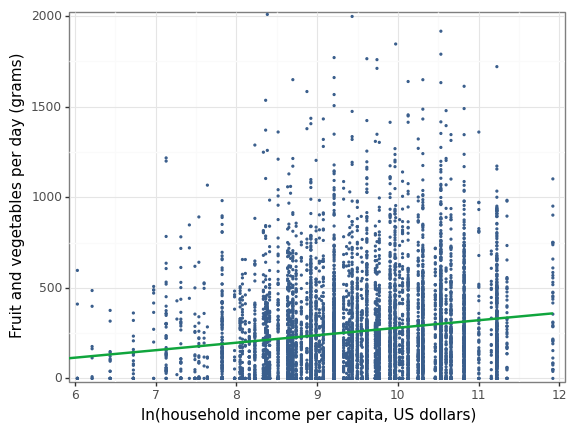

<ggplot: (377963002)>

In [20]:
# gen Log household income per capita
(
    ggplot(workfile, aes(x="lninc", y="fv"))
    + geom_point(size=0.3, alpha=0.5, color=color[0])
    + geom_smooth(method="lm", se=False, color=color[1])
    + theme_bw()
    + labs(
        x="ln(household income per capita, US dollars)",
        y="Fruit and vegetables per day (grams)",
    )
    + scale_y_continuous(expand=(0.01, 0.01), breaks=(0, 500, 1000, 1500, 2000))
    + scale_x_continuous(expand=(0.01, 0.01), breaks=(6, 7, 8, 9, 10, 11, 12))
    + coord_cartesian(xlim=(6, 12), ylim=(0, 2000), expand=True)
)

In [21]:
# Amount of fruit and vegetables per day, g (fv) vs Days per week vigorous recreational activities (exerc)
workfile.groupby("exerc").agg(tab_exerc=("year", "count"))

,tab_exerc
exerc,
0.0,5665
1.0,248
2.0,354
3.0,474
4.0,258
5.0,213
6.0,77
7.0,68


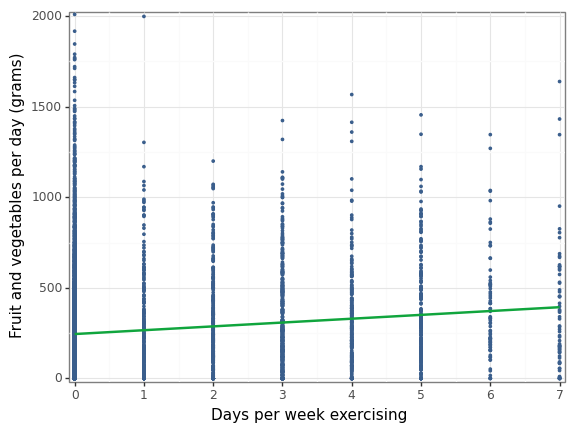

<ggplot: (377992759)>

In [22]:
(
    ggplot(workfile.dropna(subset=["exerc"]), aes(x="exerc", y="fv"))
    + geom_point(size=0.5, alpha=0.5, color=color[0])
    + geom_smooth(method="lm", se=False, color=color[1])
    + theme_bw()
    + labs(x="Days per week exercising", y="Fruit and vegetables per day (grams)")
    + scale_x_continuous(expand=(0.01, 0.01), breaks=seq(0, 7, 1))
    + scale_y_continuous(expand=(0.01, 0.01), breaks=seq(0, 2000, 500))
    + coord_cartesian(xlim=(0, 7), ylim=(0, 2000), expand=True)
)

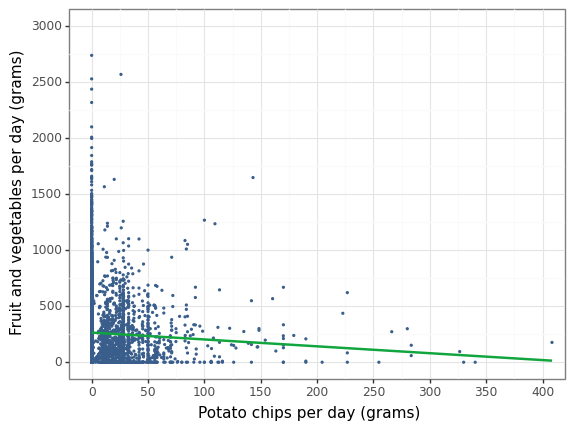

<ggplot: (378184232)>

In [23]:
# potato chips (potato_chips) and amount of fruit and vegetables per day (fv)
(
    ggplot(workfile, aes(x="pchips", y="fv"))
    + geom_point(size=0.3, alpha=0.5, color=color[0])
    + geom_smooth(method="lm", se=False, color=color[1])
    + theme_bw()
    + labs(x="Potato chips per day (grams)", y="Fruit and vegetables per day (grams)")
    + scale_x_continuous(breaks=seq(0, 400, 50))
    + scale_y_continuous(breaks=seq(0, 3000, 500))
    + coord_cartesian(xlim=(0, 400), ylim=(0, 3000), expand=True)
)

In [24]:
reg1 = smf.ols("bp ~ fv", data=workfile).fit(cov_type="HC1")
reg2 = smf.ols("fv ~ lninc", data=workfile).fit(cov_type="HC1")
reg3 = smf.ols("fv ~ exerc", data=workfile).fit(cov_type="HC1")
reg4 = smf.ols("fv ~ pchips", data=workfile).fit(cov_type="HC1")

In [25]:
stargazer = Stargazer([reg1, reg2, reg3, reg4])
stargazer.covariate_order(["Intercept", "fv", "lninc", "exerc", "pchips"])
stargazer.rename_covariates({"Intercept": "Constant"})
stargazer.custom_columns(["Model 1", "Model 2", "Model 3", "Model 3"], [1, 1, 1, 1])
stargazer.show_model_numbers(False)
HTML(stargazer.render_html())